<a href="https://colab.research.google.com/github/karolalonso70-dev/Estad-sticaVerano2026/blob/main/Student_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/karolalonso70-dev/Estad-sticaVerano2026/refs/heads/main/Studentperformance/Student_Performance.csv")

df

,Hours Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample_Question_Papers_Practiced,Performance_Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


Establecemos la horas de estudio (Hours_Studied) como variable independiente  y el indice de desempeño ("Performance_Index) como la  ariable dependiente. Esto es porque la hopotesis inicial es que cambios en las horas de estudio pueden cambiar cambios en el indice de desempeño, sin embargo cambios en los indices de desempeño no causa cambios en las horas de estudio.

In [7]:
X = df["Hours Studied"]       # Variable independient
Y = df["Performance_Index"]   # Variable dependiente

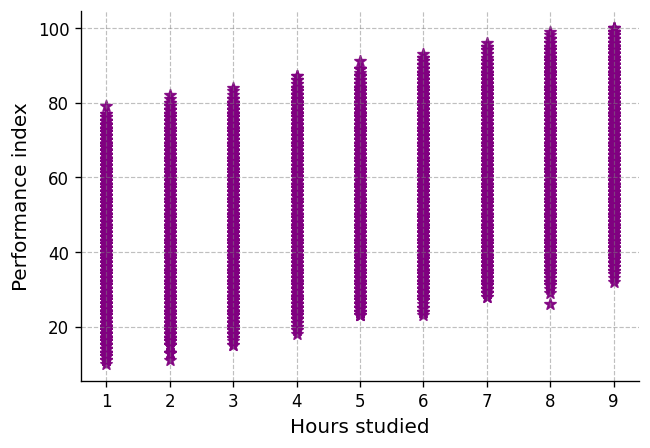

In [9]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="*",       # forma: googlear "matplotlib.markers"
    color='purple',     # color de los puntos
    edgecolor='purple',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50                  # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Hours studied', # etiqueta del eje x
    fontsize=12      # tamaño de fuente
)

plt.ylabel(
    'Performance index', # etiqueta del eje y
    fontsize=12          # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)


In [21]:

# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación: -0.8801
valor_p:  0.0000


El coeficiente de correlación lineal debil,sin embargo, la prueba de hipótesis indica que a pesar de haber una relacion debil si existe una correlación

In [18]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
yycalculada = modelo.predict(x_constante)

In [20]:
# coeficiente de determinacion
from sklearn.metrics import r2_score

r2 = r2_score(Y, yycalculada)

print(f"coeficiente de determinacion: {r2: 0.2%}")

coeficiente de determinacion:  77.46%


una vez ajustado el modelo dde regresion lineal, se obtiene un coeficiente de determinacion de